In [1]:
import numpy as np
import sys
print(sys.executable)
!{sys.executable} -m pip install pandas numpy matplotlib pillow torchsummary scikit-learn
import os
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
import sys
!{sys.executable} -m pip install pandas numpy matplotlib pillow torchsummary scikit-learn
import sys
!{sys.executable} -m pip install torch torchvision torchaudio
!{sys.executable} -m pip install numpy pandas matplotlib pillow torchsummary scikit-learn
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.utils.data import DataLoader, Dataset
from torchsummary import summary
from torch.optim.lr_scheduler import CosineAnnealingLR
import time

c:\Users\palla\.cursor\DeepLenseProject\myenv_gpu\Scripts\python.exe



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
# Setting for the the trianing 
tr_percentage = 0.1# train on provided percetage of data from the entire dataset
import torch

# Select compute device (prefers NVIDIA GPU, then Apple MPS, then CPU)
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print(f"Using device: [{device}]")
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print(f'We are using {tr_percentage*100}% of your dataset')

2.6.0+cu124
CUDA available: True
Using device: [cuda]
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
We are using 10.0% of your dataset


In [50]:
# Prepare the dataset directories 
data_path = "ifood-2019-fgvc6"
train_data = os.path.join(data_path, 'train_set')
test_data = os.path.join(data_path, 'val_set')

train_imgs = os.listdir(train_data) # get all training images files
test_imgs = os.listdir(test_data) # get all training images files
print(f'There are {len(train_imgs)} training and {len(test_imgs)} testing images')

There are 118475 training and 11994 testing images


In [51]:
# read the labels
# Safety imports in case this cell is run without re-running Cell 0
import os
import pandas as pd

pdf = pd.read_csv(os.path.join(data_path, 'train_labels.csv'))
t_pdf = pd.read_csv(os.path.join(data_path, 'val_labels.csv'))
print(f'Ther are {pdf.isna().sum().sum()} images without labels')
pdf.count()

Ther are 0 images without labels


img_name    118475
label       118475
dtype: int64

In [52]:
# read the classes value
data_classes = pd.read_csv(os.path.join(data_path, 'class_list.txt'), sep=' ') 
data_classes.columns = ['id', 'name']
NUM_CLASSES = len(data_classes)+1
print(f'There are {NUM_CLASSES} classes')
data_classes, NUM_CLASSES

There are 251 classes


(      id                 name
 0      1              beignet
 1      2              cruller
 2      3          cockle_food
 3      4               samosa
 4      5             tiramisu
 ..   ...                  ...
 245  246  chicken_cordon_bleu
 246  247          eccles_cake
 247  248      moo_goo_gai_pan
 248  249         buffalo_wing
 249  250       stuffed_tomato
 
 [250 rows x 2 columns],
 251)

In [53]:
# plot the class distribution
def plot_class_distributions(num_labels = pdf['label'], percentage = 100):
    """
    This method will plot the labels distribution passed in the histogram format
    """
    plt.figure(figsize=(12, 5))
    plt.hist(num_labels, bins=250, color='skyblue', edgecolor='black', alpha=0.8)
    plt.title(f'Distribution of {percentage}% Labels')
    plt.xlabel('Label Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

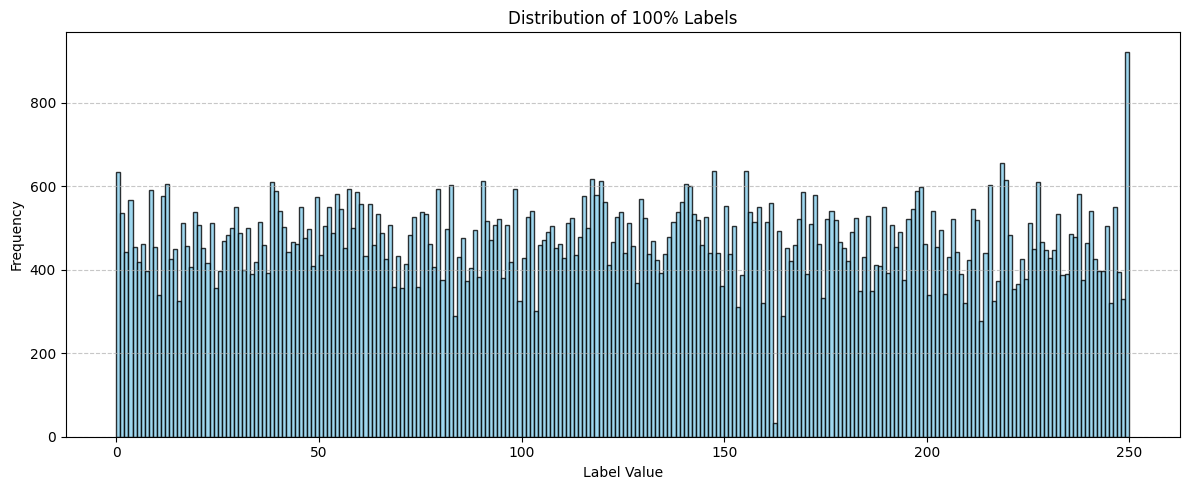

In [54]:
# plot the all class distributions 
all_classes = pdf['label']
plot_class_distributions(all_classes)

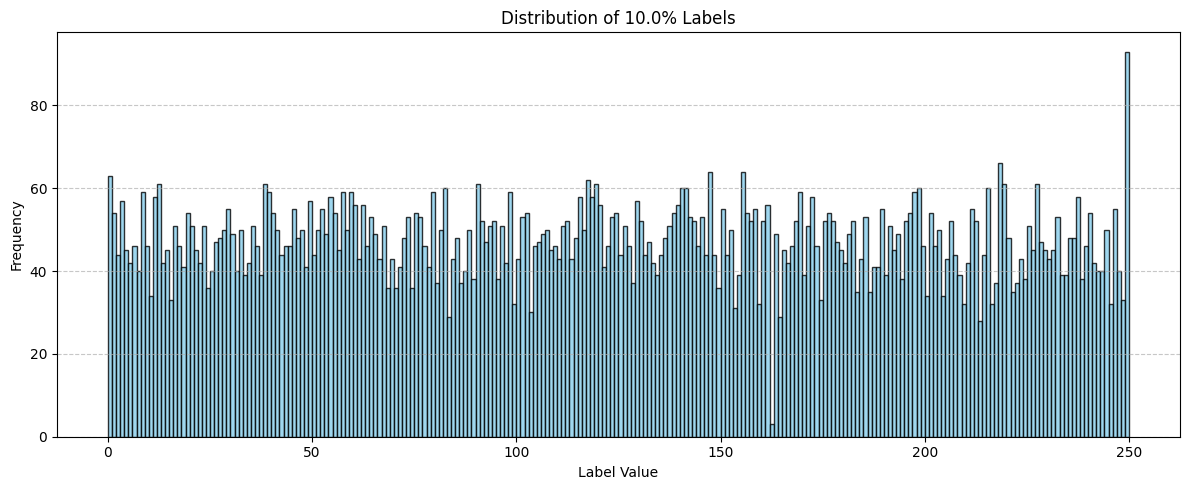

In [55]:
# Stratified sampling to get xx% from each class
trainable_pdf = pdf.groupby('label', group_keys=False).sample(frac=tr_percentage, random_state=42)
test_pdf = t_pdf.groupby('label', group_keys=False).sample(frac=tr_percentage, random_state=42)

# plot the sampled classes destribution
plot_class_distributions(trainable_pdf['label'], tr_percentage*100)


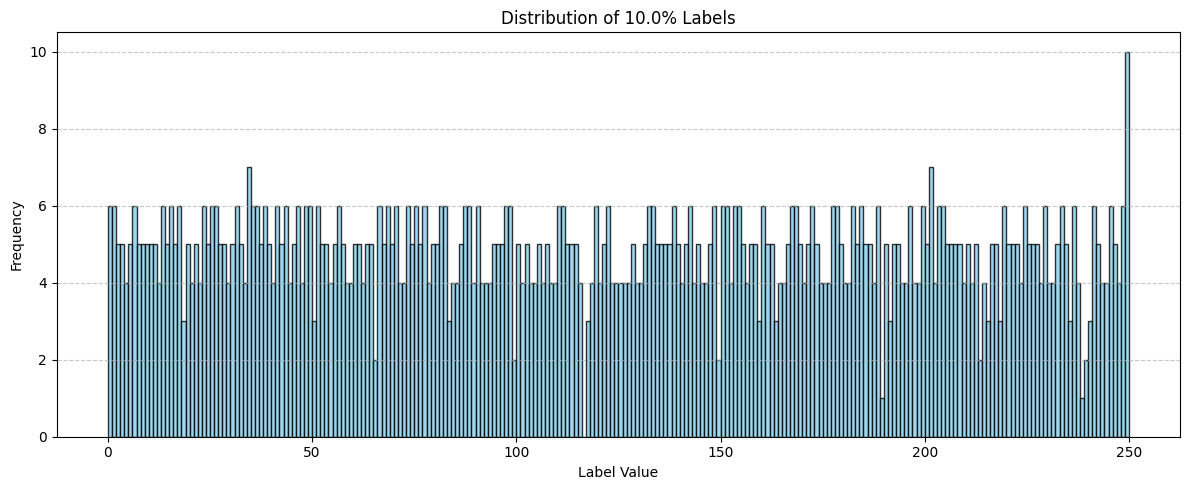

In [56]:
plot_class_distributions(test_pdf['label'], tr_percentage*100)

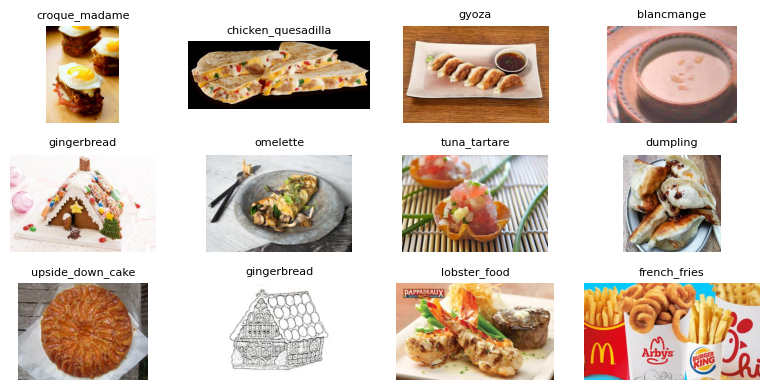

In [57]:
plt.figure(figsize=(8, 4))

for i in range(12): 
    plt.subplot(3, 4, i + 1)
    
    rand_idx = np.random.randint(len(trainable_pdf))
    rand_pdf = trainable_pdf[rand_idx-1:rand_idx]
    img_name = rand_pdf['img_name'].values[0]
    label = rand_pdf['label'].values[0]
    
    img = Image.open(os.path.join(data_path, 'train_set', img_name))
    plt.imshow(img)
    
    title_text = data_classes.iloc[label-1:label]['name'].values[0]
    plt.title(title_text, fontsize=8)
    
    plt.axis('off')

plt.tight_layout()
plt.show()


In [58]:
# Get the Mean and Std of the training dataset 
# This might take arround 8.5 minutes since I am calculating over the entire dataset
pixel_sum = np.zeros(3) # For RGB sum
pixel_sq_sum = np.zeros(3) 
total_pixels = 0

# this the final values after executing the loop 
# glb_mean = [162.75951001, 138.58583393, 113.06651858]
# glb_std = [70.29061983, 74.10972917, 80.80873226]

# Un comment this if you want to recalculate
# for img_name in train_imgs: 
#     # open image and convert to array format
#     img = np.array(Image.open(os.path.join(data_path, 'train_set', img_name))).astype(np.float32)

#     num_pixels = img.shape[0]*img.shape[1] # get the number of pixels of height and width
#     total_pixels += num_pixels # count the pixels 

#     # Sum pixels per chanel 
#     pixel_sum += np.sum(img, axis=(0, 1))
#     pixel_sq_sum += np.sum(img ** 2, axis=(0, 1))

# # final calucation 
# glb_mean = pixel_sum / total_pixels
# glb_var = (pixel_sq_sum / total_pixels) - (glb_mean ** 2)
# glb_std = np.sqrt(glb_var)
# print(glb_var)
# print("Dataset Mean (R, G, B):", glb_mean)
# print("Dataset Std  (R, G, B):", glb_std)

In [59]:
glb_mean = [162.75951001, 138.58583393, 113.06651858]
glb_std = [70.29061983, 74.10972917, 80.80873226]

In [60]:
class Myclass(Dataset):
    def __init__(self, df, dir='train_set', transform=None):
        super().__init__()
        self.df = df 
        self.dir = dir # images directory
        self.transform = transform 
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        file = self.df.iloc[idx].values
        img_name = file[0]
        label = file[1]
        img = Image.open(os.path.join(data_path, self.dir, img_name))
        if self.transform:
            img = self.transform(img)
        return img, label

In [61]:
# Create training and validation transform pipeline 
SIZE = 160
train_transform = transforms.Compose([
    transforms.Resize(size=(SIZE, SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomRotation(degrees=30),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2.0)),
    # crop a random portion and resize back to SIZE so train matches val_transform (160x160)
    transforms.RandomResizedCrop(SIZE, scale=(0.6, 1.0), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=glb_mean, std=glb_std),
])
val_transform = transforms.Compose([  
    transforms.Resize(size=(SIZE, SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=glb_mean, std =glb_std),
])

In [62]:
# split the train dataset in training (80%), validation (20%)
generator = torch.Generator().manual_seed(0) # keep the randomnes constant for the development and testing
indices = torch.randperm(len(trainable_pdf), generator=generator)

train_size = int(0.8 * len(trainable_pdf))

train_idx = indices[:train_size]
val_idx = indices[train_size:]
training_df = trainable_pdf.iloc[train_idx.tolist()].reset_index(drop=True)
validation_df = trainable_pdf.iloc[val_idx.tolist()].reset_index(drop=True)

print(f'{len(training_df)} images for training \n{len(validation_df)} images for validation \n{len(test_pdf)} images for testinng.')

9484 images for training 
2371 images for validation 
1207 images for testinng.


In [63]:
# Get the training, Validation and testing datas
train_data = Myclass(training_df, 'train_set', train_transform)
val_data = Myclass(validation_df, 'train_set', val_transform)
test_data = Myclass(test_pdf, 'val_set', val_transform)
len(train_data), len(val_data), len(test_data)

(9484, 2371, 1207)

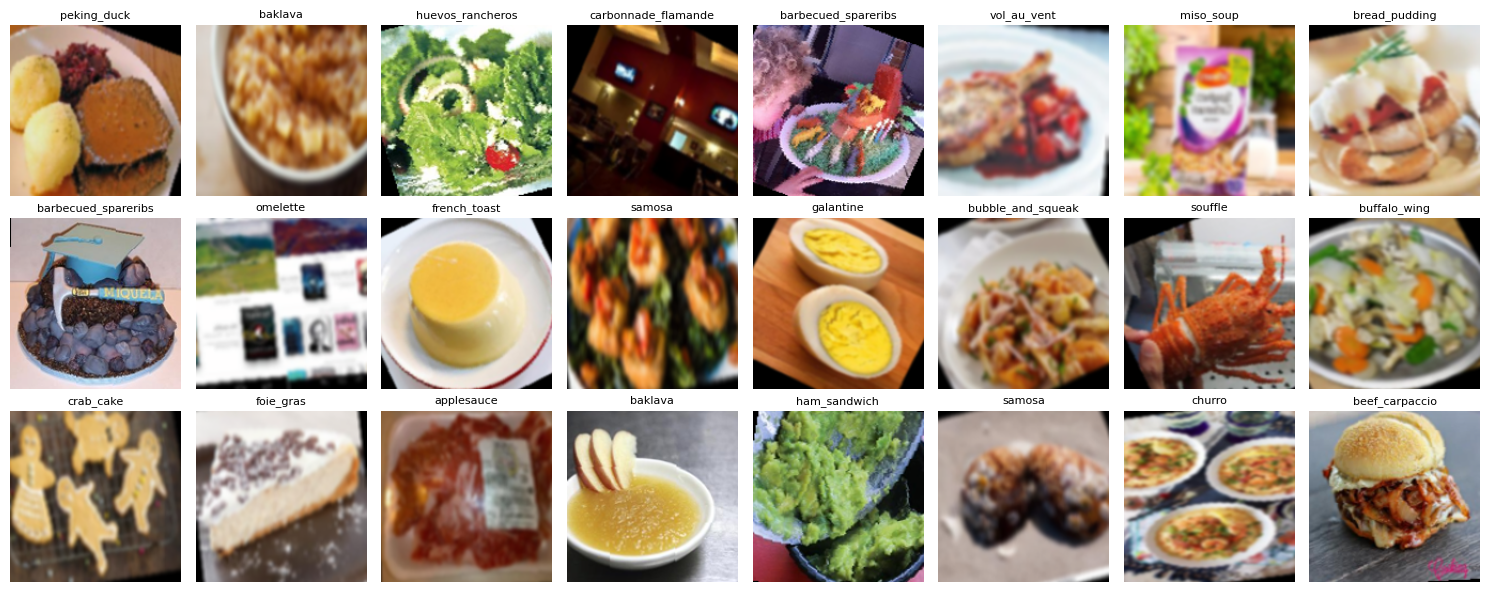

In [64]:
# plot some random augmented images 
plt.figure(figsize=(15, 6))

for i in range(24): 
    plt.subplot(3, 8, i + 1)
    
    rand_idx = np.random.randint(len(train_data))
    img, label = train_data.__getitem__(rand_idx)
    img = img.permute(1, 2, 0).numpy()

    #  denormalize
    img = glb_std * img + glb_mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    title_text = data_classes.iloc[label]['name']
    plt.title(title_text, fontsize=8)
    
    plt.axis('off')

plt.tight_layout()
plt.show()


In [65]:
# Add data loader
# Safety device setup in case this cell is run without re-running Cell 1
if 'device' not in globals():
    if torch.cuda.is_available():
        device = 'cuda'
    elif torch.backends.mps.is_available():
        device = 'mps'
    else:
        device = 'cpu'
    print(f"Using device: [{device}]")

BATCH_SIZE = 64
PIN_MEMORY = True if device == 'cuda' or device == 'mps' else False
NUM_WORKERS = 0
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, pin_memory=PIN_MEMORY, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, pin_memory=PIN_MEMORY, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, pin_memory=PIN_MEMORY, num_workers=NUM_WORKERS)
print(f"There are \n {len(train_loader)} training batches \n {len(val_loader)} validation batches \n {len(test_loader)} testing batches")


There are 
 148 training batches 
 38 validation batches 
 19 testing batches


In [66]:
# inspired by vgg-16 
# https://arxiv.org/abs/1409.1556
"""
    The network architecture inspired by VGG-16 with following update
    1. Add Batch Normalization after each Convolution layer to have a faster convergance and more stable gradient 
    2. Add Dropout layer before classification layer to raiseeduces co-adaptation of neurons
    3. only 4 blocks while VGG-16 have 5 blocks
"""

class Net(nn.Module):
    
    def __init__(self):
        super().__init__() 
        self.conv_b1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv_b2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv_b3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv_b4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2)
        ) 
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Sequential(
            nn.Linear(512, 360),
            nn.ReLU(), 
            nn.Dropout(0.3),
            nn.Linear(360, NUM_CLASSES), 
        )

    def forward(self, x):   
        x = self.conv_b1(x)
        x = self.conv_b2(x)
        x = self.conv_b3(x)
        x = self.conv_b4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1) 
        x = self.fc(x)
        return x
net = Net().to(device)
# log the total number of parameter
model_parameters = filter(lambda p: p.requires_grad, net.parameters())
params = sum([np.prod(p.size()) for p in model_parameters])
print(f'The model has {params} trainable parameters')


The model has 7915931 trainable parameters


In [67]:
summary(net, input_size=(3, 160, 160))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 160, 160]           1,792
       BatchNorm2d-2         [-1, 64, 160, 160]             128
              ReLU-3         [-1, 64, 160, 160]               0
            Conv2d-4         [-1, 64, 160, 160]          36,928
       BatchNorm2d-5         [-1, 64, 160, 160]             128
              ReLU-6         [-1, 64, 160, 160]               0
         MaxPool2d-7           [-1, 64, 80, 80]               0
            Conv2d-8          [-1, 128, 80, 80]          73,856
       BatchNorm2d-9          [-1, 128, 80, 80]             256
             ReLU-10          [-1, 128, 80, 80]               0
           Conv2d-11          [-1, 128, 80, 80]         147,584
      BatchNorm2d-12          [-1, 128, 80, 80]             256
             ReLU-13          [-1, 128, 80, 80]               0
        MaxPool2d-14          [-1, 128,

In [68]:
from collections import Counter
import torch

counts = Counter(trainable_pdf['label'])

weights = []
for c in range(251):
    weights.append(1.0 / counts[c])

weights = torch.tensor(weights, dtype=torch.float32)
weights = weights / weights.sum() * len(weights)

In [69]:
# Setup the model compiler
# Safety setup in case this cell is run after defining Net but before creating net
if 'device' not in globals():
    if torch.cuda.is_available():
        device = 'cuda'
    elif torch.backends.mps.is_available():
        device = 'mps'
    else:
        device = 'cpu'
    print(f"Using device: [{device}]")

if 'net' not in globals():
    if 'Net' not in globals():
        raise NameError("Net is not defined. Run the cell that defines class Net before this cell.")
    net = Net().to(device)
    print("Created net and moved it to device.")

EPOCHS = 30
optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1e-4)

# loss method 
loss_fun = nn.CrossEntropyLoss(weight=weights.to(device))
# per-epoch stepping
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)


In [70]:
# Create a training method
def train_model(model, dataloader, loss_fun, optimizer):
  training_loss, total, correct = 0, 0, 0 
  model.train()
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    if y.ndim == 2:
      y = y.squeeze(1)
    y = y.long()
    optimizer.zero_grad() # reset the gradient
    y_pred = model(X) # (B, C, H, W)
    loss = loss_fun(y_pred, y) # calculate the loss

    # Pixel level 
    loss.backward() # comput the gradient
    optimizer.step() # update the weight
    training_loss += loss.item()
    # Calculate the training accuracy
    preds = torch.argmax(y_pred, dim=1)
    correct += (preds == y).sum().item()
    total += y.size(0) 
    
    if (batch+1 == len(dataloader)):
      print(f'Batch {batch+1}/{len(dataloader)} | Loss: {loss.item():.4f}')
  training_acc = correct / total 
  return training_loss/len(dataloader), training_acc, 


In [71]:
# Create a validation method
def validate_model(model, dataloader, loss_fun, epoch):
  model.eval()
  val_loss, correct, total = 0, 0, 0
  with torch.no_grad():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      if y.ndim == 2:
        y = y.squeeze(1)
      y = y.long()
      y_pred = model(X)
      loss = loss_fun(y_pred, y)
      val_loss += loss.item() 
      preds = torch.argmax(y_pred, dim=1)
      # accuracy in pixel level
      correct += (preds == y).sum().item()
      total += y.size(0)

    val_acc = correct/total
  return val_loss/len(dataloader), val_acc

In [72]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [], 
}
best_val_loss = float('inf')

patience, epochs_no_improve = 10, 0
best_val_acc = 0
start_train_time = time.time()
for i in range(EPOCHS):
    print(f'Epoch {i+1}:')
    tr_loss, tr_acc = train_model(net, train_loader, loss_fun, optimizer)
    history['train_acc'].append(tr_acc)
    history['train_loss'].append(tr_loss) 
    scheduler.step()

    val_loss, val_acc = validate_model(net, val_loader, loss_fun, i+1)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss) 
    

    print(f"""
    tr loss [{tr_loss:.4f}] | val loss [{val_loss:.4f}]
    tr acc [{tr_acc:.4f}] | val acc [{val_acc:.4f}] | lr [{optimizer.param_groups[-1]['lr']:.6f}]
    """)

    # Save only weights of the best model 
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(net.state_dict(), 'best_model_weights.pth')
        print("Best model saved!")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {i+1}")
            break
torch.save(net.state_dict(), 'last_model.pth')
print(f'Last model saved correctly')
end_train_time = time.time()
print(f'End training after {(end_train_time - start_train_time)/60:.4f} minutes')



Epoch 1:
Batch 148/148 | Loss: 5.5254

    tr loss [5.5345] | val loss [5.5281]
    tr acc [0.0025] | val acc [0.0017] | lr [0.000997]
    
Best model saved!
Epoch 2:
Batch 148/148 | Loss: 5.5273

    tr loss [5.5260] | val loss [5.5295]
    tr acc [0.0049] | val acc [0.0017] | lr [0.000989]
    
Epoch 3:
Batch 148/148 | Loss: 5.5249

    tr loss [5.5257] | val loss [5.5308]
    tr acc [0.0049] | val acc [0.0017] | lr [0.000976]
    
Epoch 4:
Batch 148/148 | Loss: 5.5295

    tr loss [5.5254] | val loss [5.5320]
    tr acc [0.0045] | val acc [0.0017] | lr [0.000957]
    
Epoch 5:
Batch 148/148 | Loss: 5.5331

    tr loss [5.5251] | val loss [5.5332]
    tr acc [0.0029] | val acc [0.0017] | lr [0.000933]
    
Epoch 6:
Batch 148/148 | Loss: 5.5336

    tr loss [5.5249] | val loss [5.5343]
    tr acc [0.0034] | val acc [0.0017] | lr [0.000905]
    
Epoch 7:
Batch 148/148 | Loss: 5.5262

    tr loss [5.5246] | val loss [5.5352]
    tr acc [0.0040] | val acc [0.0017] | lr [0.000872]
    
Ep

<Axes: >

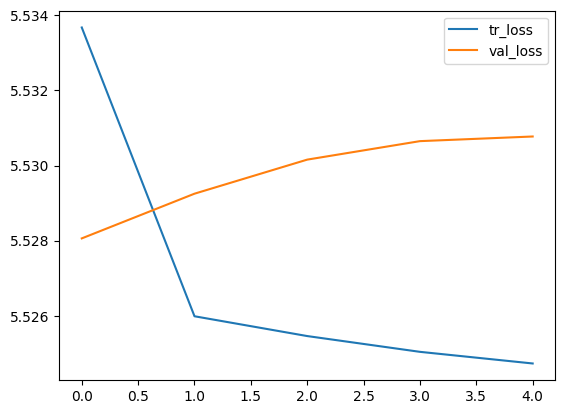

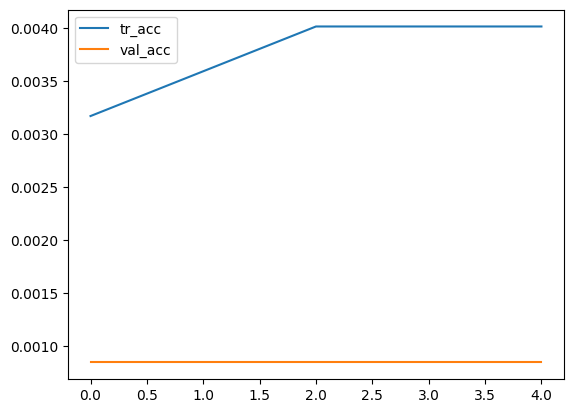

In [26]:
# Plot the learning curve 
pd.DataFrame({'tr_loss': history['train_loss'], 'val_loss': history['val_loss']}).plot()
pd.DataFrame({'tr_acc': history['train_acc'], 'val_acc': history['val_acc']}).plot()

SL Test Accuracy:  0.0050
SL Macro F1:       0.0000
SL Weighted F1:    0.0000

--- Classification Report (SL) ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.00      0.00      0.00         6
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00         5
           4       0.00      0.00      0.00         4
           5       0.00      0.00      0.00         5
           6       0.00      0.00      0.00         6
           7       0.00      0.00      0.00         5
           8       0.00      0.00      0.00         5
           9       0.00      0.00      0.00         5
          10       0.00      0.00      0.00         5
          11       0.00      0.00      0.00         5
          12       0.00      0.00      0.00         4
          13       0.00      0.00      0.00         6
          14       0.00      0.00      0.00         5
          15       0.

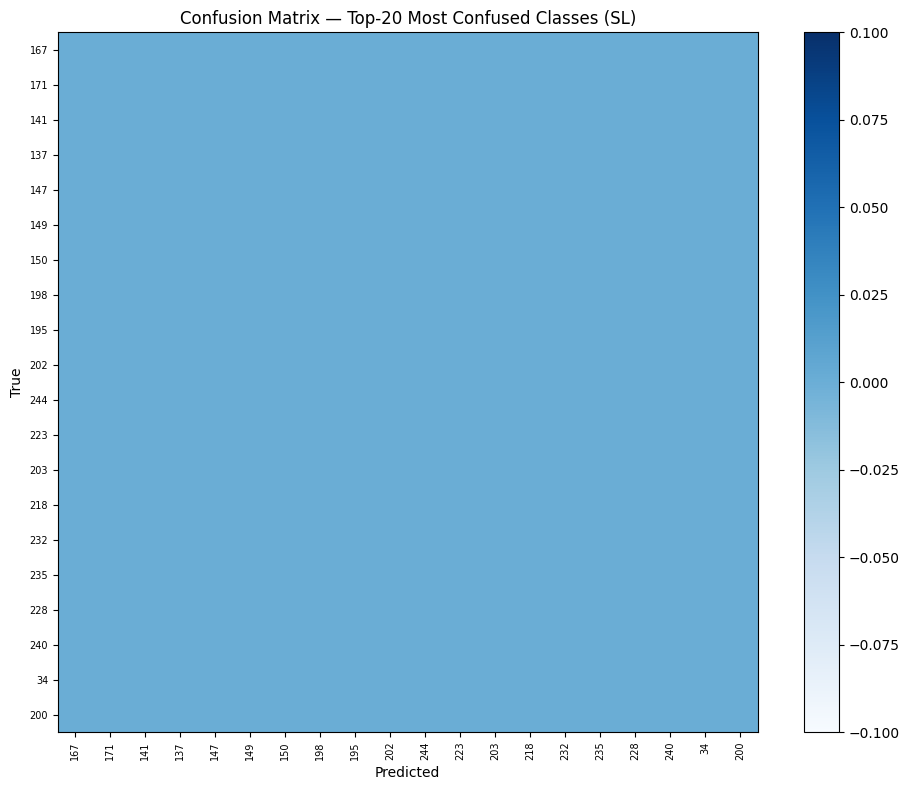

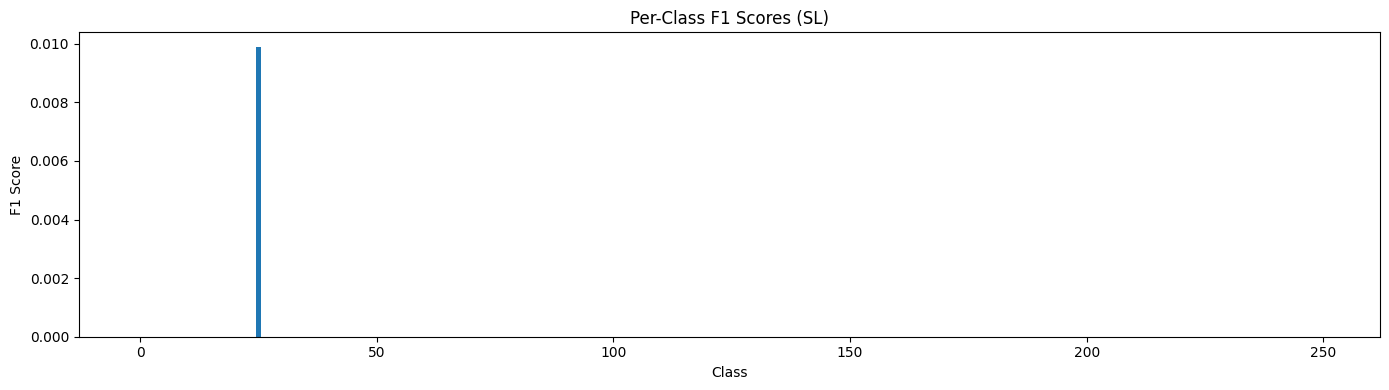

In [27]:
# --- Part A: Load best SL checkpoint and evaluate on test set ---
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# ponytail: reusing 'best_model_weights.pth' already saved by Cell 24
net.load_state_dict(torch.load('best_model_weights.pth', map_location=device, weights_only=True))
net.eval()

sl_preds, sl_labels = [], []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        if y.ndim == 2:
            y = y.squeeze(1)
        preds = torch.argmax(net(X), dim=1).cpu().numpy()
        sl_preds.extend(preds)
        sl_labels.extend(y.numpy())

sl_preds = np.array(sl_preds)
sl_labels = np.array(sl_labels)

sl_accuracy = accuracy_score(sl_labels, sl_preds)
sl_f1_macro = f1_score(sl_labels, sl_preds, average='macro', zero_division=0)
sl_f1_weighted = f1_score(sl_labels, sl_preds, average='weighted', zero_division=0)

print(f"SL Test Accuracy:  {sl_accuracy:.4f}")
print(f"SL Macro F1:       {sl_f1_macro:.4f}")
print(f"SL Weighted F1:    {sl_f1_weighted:.4f}")
print("\n--- Classification Report (SL) ---")
print(classification_report(sl_labels, sl_preds, zero_division=0))

# Confusion matrix heatmap — top-20 most confused classes
# ponytail: 251 classes too dense for a heatmap; pick 20 with most off-diagonal errors
cm = confusion_matrix(sl_labels, sl_preds)
off_diag = cm.sum(axis=1) - np.diag(cm)
top20_idx = np.argsort(off_diag)[-20:]
cm_top20 = cm[np.ix_(top20_idx, top20_idx)]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_top20, cmap='Blues')
ax.set_xticks(range(20))
ax.set_yticks(range(20))
ax.set_xticklabels(top20_idx, rotation=90, fontsize=7)
ax.set_yticklabels(top20_idx, fontsize=7)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Top-20 Most Confused Classes (SL)')
fig.colorbar(im)
plt.tight_layout()
plt.show()

# Per-class F1 bar chart
per_class_f1 = f1_score(sl_labels, sl_preds, average=None, zero_division=0)
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(per_class_f1)), per_class_f1, width=1.0)
ax.set_xlabel('Class')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Scores (SL)')
plt.tight_layout()
plt.show()

In [28]:
# --- Hyperparameter Summary (SL) ---
summary_data = {
    'Parameter': ['Image Size', 'Batch Size', 'Epochs', 'Optimizer', 'Learning Rate',
                   'Scheduler', 'Weight Decay', 'Augmentations',
                   'Final Val Accuracy', 'Final Test Accuracy', 'Test Macro F1'],
    'Value': [f'{SIZE}x{SIZE}', BATCH_SIZE, EPOCHS, 'AdamW', '1e-3',
              'CosineAnnealingLR', '1e-4',
              'Resize, Rotation, HFlip, GaussianBlur, RandomCrop, Normalize',
              f"{history['val_acc'][-1]:.4f}", f"{sl_accuracy:.4f}", f"{sl_f1_macro:.4f}"]
}
print(pd.DataFrame(summary_data).to_string(index=False))

          Parameter                                                        Value
         Image Size                                                      160x160
         Batch Size                                                           64
             Epochs                                                            5
          Optimizer                                                        AdamW
      Learning Rate                                                         1e-3
          Scheduler                                            CosineAnnealingLR
       Weight Decay                                                         1e-4
      Augmentations Resize, Rotation, HFlip, GaussianBlur, RandomCrop, Normalize
 Final Val Accuracy                                                       0.0008
Final Test Accuracy                                                       0.0050
      Test Macro F1                                                       0.0000


In [29]:
# --- Part B1: SimCLR augmentation pipeline and paired dataset ---
ssl_transform = transforms.Compose([
    transforms.Resize((SIZE, SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomResizedCrop(SIZE, scale=(0.2, 1.0), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=9),
    transforms.ToTensor(),
    transforms.Normalize(mean=glb_mean, std=glb_std),
])

class SimCLRDataset(Dataset):
    """Returns two differently-augmented views of the same image (labels ignored)."""
    def __init__(self, df, dir, transform):
        self.df = df
        self.dir = dir
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['img_name']
        img = Image.open(os.path.join(data_path, self.dir, img_name)).convert('RGB')
        return self.transform(img), self.transform(img)

ssl_dataset = SimCLRDataset(trainable_pdf, 'train_set', ssl_transform)
ssl_loader = DataLoader(ssl_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
print(f"SSL dataset: {len(ssl_dataset)} images, {len(ssl_loader)} batches")

SSL dataset: 11855 images, 185 batches


In [30]:
# --- Part B2: SimCLR model — reuses Net's conv blocks + projection head ---
import torch.nn.functional as F

class SimCLRNet(nn.Module):
    def __init__(self, backbone, projection_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            backbone.conv_b1,
            backbone.conv_b2,
            backbone.conv_b3,
            backbone.conv_b4,
            backbone.avgpool,
        )
        # ponytail: 512 known from Net's conv_b4 output channels + AdaptiveAvgPool2d(1,1)
        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, projection_dim),
        )

    def forward(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        return self.projector(h)

    def get_features(self, x):
        """Encoder output without projection head — used for downstream tasks."""
        h = self.encoder(x)
        return h.view(h.size(0), -1)

ssl_backbone = Net()  # fresh backbone for SSL (no pretrained weights)
ssl_net = SimCLRNet(ssl_backbone).to(device)
print(f"SimCLRNet parameters: {sum(p.numel() for p in ssl_net.parameters()):,}")

SimCLRNet parameters: 7,804,864


In [31]:
# --- Part B3: NT-Xent (contrastive) loss ---
def nt_xent_loss(z1, z2, temperature=0.5):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    N = z1.size(0)
    z = torch.cat([z1, z2], dim=0)         # (2N, D)
    sim = torch.mm(z, z.T) / temperature   # (2N, 2N)
    # mask out self-similarities
    mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
    sim.masked_fill_(mask, float('-inf'))
    # positive pair for i is i+N (and vice versa)
    labels = torch.cat([torch.arange(N, 2 * N), torch.arange(0, N)]).to(z.device)
    return F.cross_entropy(sim, labels)

Batch 185/185 | Loss: 4.8442
SSL Epoch 1/10 | Avg Loss: 4.8445
Best SSL model saved!
Batch 185/185 | Loss: 4.8428
SSL Epoch 2/10 | Avg Loss: 4.8442
Best SSL model saved!
Batch 185/185 | Loss: 4.3377
SSL Epoch 3/10 | Avg Loss: 4.5879
Best SSL model saved!
Batch 185/185 | Loss: 4.2968
SSL Epoch 4/10 | Avg Loss: 4.4127
Best SSL model saved!
Batch 185/185 | Loss: 4.0619
SSL Epoch 5/10 | Avg Loss: 4.2028
Best SSL model saved!
Batch 185/185 | Loss: 4.0301
SSL Epoch 6/10 | Avg Loss: 4.0520
Best SSL model saved!
Batch 185/185 | Loss: 3.8772
SSL Epoch 7/10 | Avg Loss: 3.9150
Best SSL model saved!
Batch 185/185 | Loss: 3.7656
SSL Epoch 8/10 | Avg Loss: 3.8257
Best SSL model saved!
Batch 185/185 | Loss: 3.7612
SSL Epoch 9/10 | Avg Loss: 3.7944
Best SSL model saved!
Batch 185/185 | Loss: 3.6567
SSL Epoch 10/10 | Avg Loss: 3.7767
Best SSL model saved!

SSL training finished in 508.33 minutes


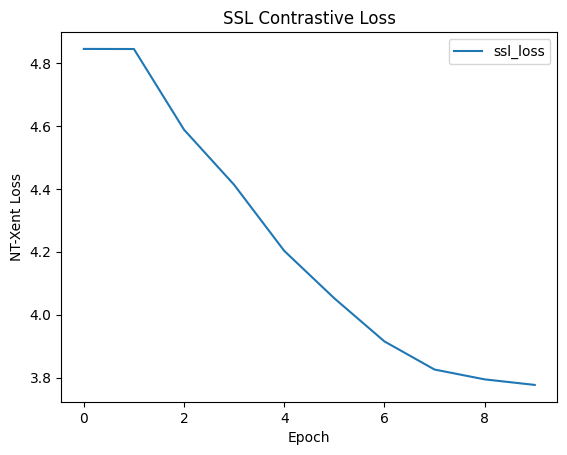

In [32]:
# --- Part B4: SSL training loop ---
SSL_EPOCHS = 10
ssl_optimizer = torch.optim.AdamW(ssl_net.parameters(), lr=1e-3, weight_decay=1e-4)
ssl_scheduler = CosineAnnealingLR(ssl_optimizer, T_max=SSL_EPOCHS, eta_min=1e-6)

best_ssl_loss = float('inf')
ssl_history = {'ssl_loss': []}
start_ssl_time = time.time()

for epoch in range(SSL_EPOCHS):
    ssl_net.train()
    epoch_loss = 0
    for batch_idx, (x1, x2) in enumerate(ssl_loader):
        x1, x2 = x1.to(device), x2.to(device)
        z1, z2 = ssl_net(x1), ssl_net(x2)
        loss = nt_xent_loss(z1, z2)
        ssl_optimizer.zero_grad()
        loss.backward()
        ssl_optimizer.step()
        epoch_loss += loss.item()
        if batch_idx + 1 == len(ssl_loader):
            print(f"Batch {batch_idx+1}/{len(ssl_loader)} | Loss: {loss.item():.4f}")
    ssl_scheduler.step()
    avg_loss = epoch_loss / len(ssl_loader)
    ssl_history['ssl_loss'].append(avg_loss)
    print(f"SSL Epoch {epoch+1}/{SSL_EPOCHS} | Avg Loss: {avg_loss:.4f}")
    if avg_loss < best_ssl_loss:
        best_ssl_loss = avg_loss
        torch.save(ssl_net.state_dict(), 'best_model_ssl.pth')
        print("Best SSL model saved!")

ssl_train_time = time.time() - start_ssl_time
print(f"\nSSL training finished in {ssl_train_time/60:.2f} minutes")

pd.DataFrame(ssl_history).plot(title='SSL Contrastive Loss')
plt.ylabel('NT-Xent Loss')
plt.xlabel('Epoch')
plt.show()

In [34]:
# --- Part B5+B6: Feature extraction + Logistic Regression on SSL features ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

ssl_net.load_state_dict(torch.load('best_model_ssl.pth', map_location=device, weights_only=True))
ssl_net.eval()

def extract_features(model, loader, device):
    """Extract encoder features (no projection head) and labels from a DataLoader."""
    features, labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            feat = model.get_features(X)
            features.append(feat.cpu().numpy())
            labels.append(y.numpy() if isinstance(y, torch.Tensor) else y)
    return np.concatenate(features), np.concatenate(labels)

# ponytail: reuse extracted features if this cell failed after extraction and is rerun
if not all(name in globals() for name in ['train_features_ssl', 'train_labels_ssl', 'test_features_ssl', 'test_labels_ssl']):
    # ponytail: reusing existing val_transform for clean (unaugmented) feature extraction
    feat_train_ds = Myclass(training_df, 'train_set', val_transform)
    feat_test_ds = Myclass(test_pdf, 'val_set', val_transform)
    feat_train_loader = DataLoader(feat_train_ds, batch_size=BATCH_SIZE, shuffle=False)
    feat_test_loader = DataLoader(feat_test_ds, batch_size=BATCH_SIZE, shuffle=False)

    train_features_ssl, train_labels_ssl = extract_features(ssl_net, feat_train_loader, device)
    test_features_ssl, test_labels_ssl = extract_features(ssl_net, feat_test_loader, device)

print(f"Train features: {train_features_ssl.shape}, Test features: {test_features_ssl.shape}")

# Logistic Regression linear probe
scaler = StandardScaler()
X_train_ssl = scaler.fit_transform(train_features_ssl)
X_test_ssl = scaler.transform(test_features_ssl)

# scikit-learn 1.8 chooses multinomial multiclass automatically for lbfgs
clf = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
clf.fit(X_train_ssl, train_labels_ssl)
y_pred_ssl = clf.predict(X_test_ssl)

ssl_accuracy = accuracy_score(test_labels_ssl, y_pred_ssl)
ssl_f1_macro = f1_score(test_labels_ssl, y_pred_ssl, average='macro', zero_division=0)
ssl_f1_weighted = f1_score(test_labels_ssl, y_pred_ssl, average='weighted', zero_division=0)

print(f"\nSSL + Logistic Regression Results:")
print(f"Accuracy:      {ssl_accuracy:.4f}")
print(f"Macro F1:      {ssl_f1_macro:.4f}")
print(f"Weighted F1:   {ssl_f1_weighted:.4f}")
print("\n--- Classification Report (SSL) ---")
print(classification_report(test_labels_ssl, y_pred_ssl, zero_division=0))

Train features: (9484, 512), Test features: (1207, 512)

SSL + Logistic Regression Results:
Accuracy:      0.0307
Macro F1:      0.0243
Weighted F1:   0.0259

--- Classification Report (SSL) ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.00      0.00      0.00         6
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00         5
           4       0.00      0.00      0.00         4
           5       0.00      0.00      0.00         5
           6       0.25      0.17      0.20         6
           7       0.00      0.00      0.00         5
           8       0.00      0.00      0.00         5
           9       0.00      0.00      0.00         5
          10       0.00      0.00      0.00         5
          11       0.00      0.00      0.00         5
          12       0.00      0.00      0.00         4
          13       0.14      0.17      0.15     

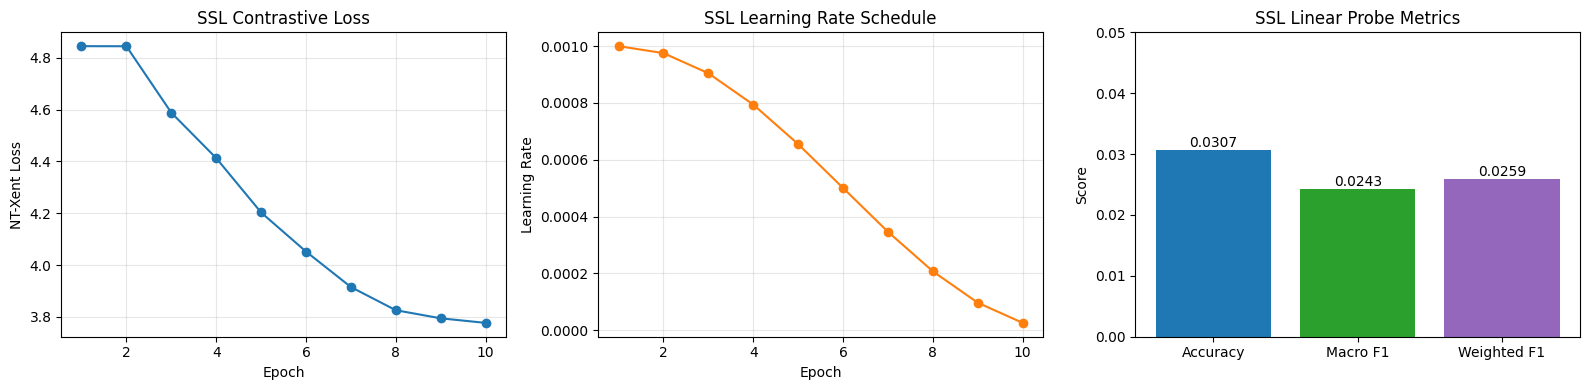

In [73]:
# --- SSL Diagnostic Curves (no retraining) ---
# Uses the completed SimCLR run; falls back to logged values if ssl_history is not in memory.
ssl_loss_values = ssl_history['ssl_loss'] if 'ssl_history' in globals() and 'ssl_loss' in ssl_history else [
    4.8445, 4.8442, 4.5879, 4.4127, 4.2028,
    4.0520, 3.9150, 3.8257, 3.7944, 3.7767,
]
ssl_epochs = np.arange(1, len(ssl_loss_values) + 1)

# Reconstruct the cosine LR schedule used by Cell 31 without re-running SSL.
ssl_base_lr = 1e-3
ssl_eta_min = 1e-6
ssl_t_max = SSL_EPOCHS if 'SSL_EPOCHS' in globals() else len(ssl_loss_values)
ssl_lr_values = [
    ssl_eta_min + 0.5 * (ssl_base_lr - ssl_eta_min) * (1 + np.cos(np.pi * epoch / ssl_t_max))
    for epoch in range(len(ssl_loss_values))
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(ssl_epochs, ssl_loss_values, marker='o')
axes[0].set_title('SSL Contrastive Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('NT-Xent Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(ssl_epochs, ssl_lr_values, marker='o', color='tab:orange')
axes[1].set_title('SSL Learning Rate Schedule')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].grid(True, alpha=0.3)

if all(name in globals() for name in ['ssl_accuracy', 'ssl_f1_macro', 'ssl_f1_weighted']):
    ssl_metric_names = ['Accuracy', 'Macro F1', 'Weighted F1']
    ssl_metric_values = [ssl_accuracy, ssl_f1_macro, ssl_f1_weighted]
    axes[2].bar(ssl_metric_names, ssl_metric_values, color=['tab:blue', 'tab:green', 'tab:purple'])
    axes[2].set_ylim(0, max(0.05, max(ssl_metric_values) * 1.15))
    axes[2].set_title('SSL Linear Probe Metrics')
    axes[2].set_ylabel('Score')
    for idx, value in enumerate(ssl_metric_values):
        axes[2].text(idx, value, f'{value:.4f}', ha='center', va='bottom')
else:
    axes[2].axis('off')
    axes[2].text(
        0.5, 0.5,
        'Run Cell 32 first\nto show SSL linear-probe metrics',
        ha='center', va='center', fontsize=11,
    )

plt.tight_layout()
plt.show()

             Metric       Supervised (SL) Self-Supervised (SSL)
           Accuracy                0.0050                0.0307
           Macro F1                0.0000                0.0243
        Weighted F1                0.0000                0.0259
         Parameters             7,915,931             7,804,864
Training Time (min)                278.22                508.33
           Approach End-to-end supervised SimCLR + Linear probe


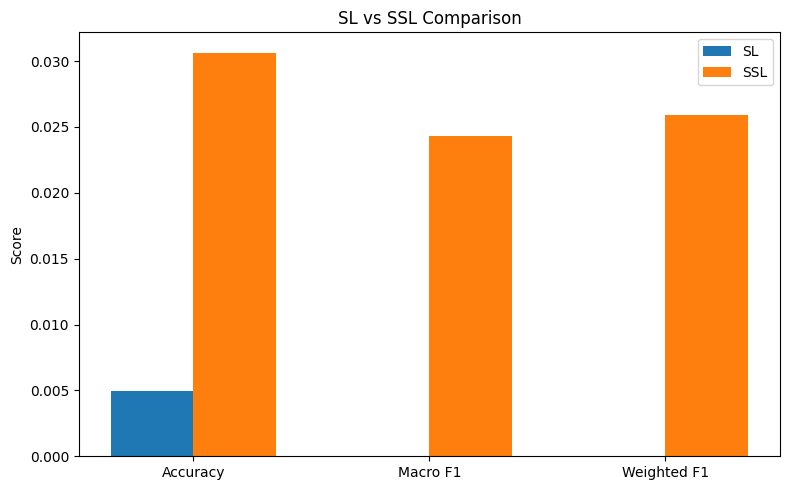

In [74]:
# --- Part C: SL vs SSL comparison ---
sl_params = sum(p.numel() for p in net.parameters())
ssl_params = sum(p.numel() for p in ssl_net.parameters())

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro F1', 'Weighted F1',
               'Parameters', 'Training Time (min)', 'Approach'],
    'Supervised (SL)': [
        f"{sl_accuracy:.4f}", f"{sl_f1_macro:.4f}", f"{sl_f1_weighted:.4f}",
        f"{sl_params:,}",
        f"{(end_train_time - start_train_time)/60:.2f}",
        'End-to-end supervised'
    ],
    'Self-Supervised (SSL)': [
        f"{ssl_accuracy:.4f}", f"{ssl_f1_macro:.4f}", f"{ssl_f1_weighted:.4f}",
        f"{ssl_params:,}",
        f"{ssl_train_time/60:.2f}",
        'SimCLR + Linear probe'
    ]
})
print(comparison.to_string(index=False))

# Side-by-side bar chart
metrics = ['Accuracy', 'Macro F1', 'Weighted F1']
sl_vals = [sl_accuracy, sl_f1_macro, sl_f1_weighted]
ssl_vals = [ssl_accuracy, ssl_f1_macro, ssl_f1_weighted]

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, sl_vals, width, label='SL')
ax.bar(x + width / 2, ssl_vals, width, label='SSL')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('SL vs SSL Comparison')
ax.legend()
plt.tight_layout()
plt.show()

## Discussion: Supervised vs Self-Supervised Learning

**Interpreting the SL and SSL comparison:**
This experiment uses 10% of the iFood-2019 training data while preserving all 251 classes. After the internal 80/20 split, the supervised model trains on 9,484 images and validates on 2,371 images; the SSL pretraining stage uses the full sampled subset without labels (~11,855 images). This is still a small amount of data for a fine-grained 251-class food recognition task, so both approaches are expected to perform far below what a larger model trained on the full dataset could achieve.

**Why SSL may underperform or match SL:**
The supervised model is optimized directly for the 251-way classification objective, so every update uses label information. SimCLR first learns representations by making two augmented views of the same image similar while pushing different images apart, then a traditional classifier is trained on the frozen features. This two-stage setup can be less sample-efficient when the dataset is small and the encoder is trained for only a few epochs. At the same time, SSL can still learn useful visual features because it sees the images without relying on labels, which makes it a meaningful comparison against end-to-end SL.

**Role of data augmentation:**
Augmentation has different roles in the two pipelines. In SL, augmentations such as rotation, flipping, blur, and random resized crop act as regularization and help reduce overfitting. In SimCLR, augmentation is the learning signal: the model learns invariances by comparing two different views of the same image. Strong augmentations such as color jitter, grayscale conversion, blur, and random crops are therefore essential for SSL, but if they are too aggressive they can also remove class-relevant visual details.

**Limitations of the current setup:**
- **10% data subset**: useful for computational feasibility, but still limited for 251 fine-grained classes.
- **Custom CNN under 10M parameters**: satisfies the project constraint, but is smaller and shallower than common SSL backbones.
- **SL tuning was limited**: the final SL run fixes the train/evaluation image-size mismatch, softens augmentation, and trains longer, but it is not an exhaustive hyperparameter search.
- **SSL pretraining is short**: SimCLR was trained for 10 epochs, while contrastive methods often benefit from many more epochs and larger batches.
- **Linear probe evaluation is strict**: the SSL encoder is frozen before logistic regression; fine-tuning the encoder could improve results but would be a different evaluation protocol.
- **Batch size of 64**: acceptable for this GPU, but SimCLR usually benefits from larger batches because they provide more negative examples per step.